<a href="https://colab.research.google.com/github/Brunomdspro/MINI_PROJETO_BRUNOMONTEIRO/blob/main/df_limpo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Base Varejo.csv", sep=';')


In [31]:
print("Current columns of the DataFrame:")
print(df.columns.tolist())

# Based on the kernel state, the columns are already translated.
# If this were not the case, the following code would be used:
# df = df.rename(columns=column_mapping)
# print("Columns after renaming:")
# print(df.columns.tolist())

Current columns of the DataFrame:
['Data', 'ID_Cliente', 'ID_Transacao', 'Genero_Cliente', 'Estado_Civil_Cliente', 'Historico_Familiar_Cliente', 'Segmento_Cliente', 'ID_Produto', 'Categoria_Produto', 'Nome_Produto']


In [32]:
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

print("\nInformações concisas do DataFrame:")
df.info()

print("\nEstatísticas descritivas do DataFrame:")
print(df.describe(include='all'))

Primeiras 5 linhas do DataFrame:
        Data  ID_Cliente  ID_Transacao Genero_Cliente  Estado_Civil_Cliente  \
0 2019-01-02        1000           534              M                     4   
1 2019-01-02        1000           534              M                     4   
2 2019-01-02        1000           534              M                     4   
3 2019-01-02        1000           534              M                     4   
4 2019-01-02        1000           534              M                     4   

   Historico_Familiar_Cliente Segmento_Cliente  ID_Produto Categoria_Produto  \
0                           1                C          67           BEBIDAS   
1                           1                C          70           BEBIDAS   
2                           1                C         178           HIGIENE   
3                           1                C           4         ALIMENTOS   
4                           1                C         175           LIMPEZA   

           

In [33]:
nulos_count = df.isnull().sum()
nulos_percent = 100 * df.isnull().sum() / len(df)
nulos_table = pd.DataFrame({'Contagem de Nulos': nulos_count, 'Porcentagem (%)': nulos_percent})
nulos_table = nulos_table[nulos_table['Contagem de Nulos'] > 0].sort_values(by='Porcentagem (%)', ascending=False)

print("Valores Nulos no DataFrame (Contagem e Porcentagem):")
print(nulos_table)

Valores Nulos no DataFrame (Contagem e Porcentagem):
      Contagem de Nulos  Porcentagem (%)
Data             428636        58.441305


In [34]:
num_duplicated_rows = df.duplicated().sum()
print(f"Número de linhas duplicadas no DataFrame: {num_duplicated_rows}")

Número de linhas duplicadas no DataFrame: 0


In [35]:
df_cleaned_date = df.dropna(subset=['Data']).copy()

print(f"Shape do DataFrame após remover nulos na coluna 'Data': {df_cleaned_date.shape}")
print(f"Contagem de nulos na coluna 'Data' após tratamento: {df_cleaned_date['Data'].isnull().sum()}")

Shape do DataFrame após remover nulos na coluna 'Data': (304811, 10)
Contagem de nulos na coluna 'Data' após tratamento: 0


In [36]:
print(f"Shape do DataFrame antes da remoção de duplicatas: {df_cleaned_date.shape}")

num_duplicated_rows_after_null_handling = df_cleaned_date.duplicated().sum()
print(f"Número de linhas duplicadas no DataFrame após tratamento de nulos: {num_duplicated_rows_after_null_handling}")

if num_duplicated_rows_after_null_handling > 0:
    df_cleaned_no_duplicates = df_cleaned_date.drop_duplicates().reset_index(drop=True)
    print(f"Shape do DataFrame após remover duplicatas: {df_cleaned_no_duplicates.shape}")
else:
    print("Não há duplicatas para remover no DataFrame após tratamento de nulos.")
    df_cleaned_no_duplicates = df_cleaned_date.copy()

Shape do DataFrame antes da remoção de duplicatas: (304811, 10)
Número de linhas duplicadas no DataFrame após tratamento de nulos: 0
Não há duplicatas para remover no DataFrame após tratamento de nulos.


In [37]:
print("Informações do DataFrame antes da conversão de tipos:")
df_cleaned_no_duplicates.info()

# Convertendo colunas para tipo 'category' para otimização
for col in ['Genero_Cliente', 'Estado_Civil_Cliente', 'Historico_Familiar_Cliente', 'Segmento_Cliente', 'Categoria_Produto', 'Nome_Produto']:
    if col in df_cleaned_no_duplicates.columns:
        df_cleaned_no_duplicates[col] = df_cleaned_no_duplicates[col].astype('category')

print("\nInformações do DataFrame após a conversão de tipos:")
df_cleaned_no_duplicates.info()

Informações do DataFrame antes da conversão de tipos:
<class 'pandas.core.frame.DataFrame'>
Index: 304811 entries, 0 to 821680
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Data                        304811 non-null  datetime64[ns]
 1   ID_Cliente                  304811 non-null  int64         
 2   ID_Transacao                304811 non-null  int64         
 3   Genero_Cliente              304811 non-null  object        
 4   Estado_Civil_Cliente        304811 non-null  int64         
 5   Historico_Familiar_Cliente  304811 non-null  int64         
 6   Segmento_Cliente            304811 non-null  object        
 7   ID_Produto                  304811 non-null  int64         
 8   Categoria_Produto           304811 non-null  object        
 9   Nome_Produto                304811 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage:

In [38]:
text_cols = ['Genero_Cliente', 'Segmento_Cliente', 'Categoria_Produto', 'Nome_Produto']

for col in text_cols:
    # Convert to string first to apply string methods, then to uppercase and strip whitespace
    df_cleaned_no_duplicates[col] = df_cleaned_no_duplicates[col].astype(str).str.upper().str.strip()

    # Special handling for 'Categoria_Produto' to replace '#N/D'
    if col == 'Categoria_Produto':
        df_cleaned_no_duplicates[col] = df_cleaned_no_duplicates[col].replace({'#N/D': 'NAO_DEFINIDA'})

    # Convert back to category type for optimization
    df_cleaned_no_duplicates[col] = df_cleaned_no_duplicates[col].astype('category')

    print(f"\nValores únicos e suas contagens para '{col}' após padronização:")
    print(df_cleaned_no_duplicates[col].value_counts())



Valores únicos e suas contagens para 'Genero_Cliente' após padronização:
Genero_Cliente
F    160513
M    144298
Name: count, dtype: int64

Valores únicos e suas contagens para 'Segmento_Cliente' após padronização:
Segmento_Cliente
B    195608
C     83783
A     25420
Name: count, dtype: int64

Valores únicos e suas contagens para 'Categoria_Produto' após padronização:
Categoria_Produto
ALIMENTOS       159872
HIGIENE          57273
LIMPEZA          53355
BEBIDAS          15771
PET              11896
ACESSORIOS        5327
NAO_DEFINIDA      1317
Name: count, dtype: int64

Valores únicos e suas contagens para 'Nome_Produto' após padronização:
Nome_Produto
PRESUNTO COZIDO    5313
BANANA             2772
MODELADOR          2758
SARDINHA           2756
LATA DE ERVILHA    2748
                   ... 
ABACAXI            1343
ALHO               1325
#N/D               1317
ABACATE            1307
ALCOOL             1306
Name: count, Length: 118, dtype: int64


In [39]:
print("\nValores únicos e suas contagens para 'Estado_Civil_Cliente':")
print(df_cleaned_no_duplicates['Estado_Civil_Cliente'].value_counts().sort_index())

print("\nValores únicos e suas contagens para 'Historico_Familiar_Cliente':")
print(df_cleaned_no_duplicates['Historico_Familiar_Cliente'].value_counts().sort_index())


Valores únicos e suas contagens para 'Estado_Civil_Cliente':
Estado_Civil_Cliente
1    70640
2    70713
3    79725
4    75343
5     8390
Name: count, dtype: int64

Valores únicos e suas contagens para 'Historico_Familiar_Cliente':
Historico_Familiar_Cliente
0    160836
1     37970
2     38516
3     39301
4     28188
Name: count, dtype: int64


In [40]:
df_limpo = df_cleaned_no_duplicates.copy()

print("Primeiras 5 linhas do DataFrame final (df_limpo):")
print(df_limpo.head())

print("\nInformações concisas do DataFrame final (df_limpo):")
df_limpo.info()

Primeiras 5 linhas do DataFrame final (df_limpo):
        Data  ID_Cliente  ID_Transacao Genero_Cliente Estado_Civil_Cliente  \
0 2019-01-02        1000           534              M                    4   
1 2019-01-02        1000           534              M                    4   
2 2019-01-02        1000           534              M                    4   
3 2019-01-02        1000           534              M                    4   
4 2019-01-02        1000           534              M                    4   

  Historico_Familiar_Cliente Segmento_Cliente  ID_Produto Categoria_Produto  \
0                          1                C          67           BEBIDAS   
1                          1                C          70           BEBIDAS   
2                          1                C         178           HIGIENE   
3                          1                C           4         ALIMENTOS   
4                          1                C         175           LIMPEZA   

      

In [57]:
display(df_limpo)

,Data,ID_Cliente,ID_Transacao,Genero_Cliente,Estado_Civil_Cliente,Historico_Familiar_Cliente,Segmento_Cliente,ID_Produto,Categoria_Produto,Nome_Produto
0,2019-01-02,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-01-02,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-01-02,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-01-02,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-01-02,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO
...,...,...,...,...,...,...,...,...,...,...
821676,2022-08-12,911308,558,F,5,2,C,35,ALIMENTOS,LATA DE ERVILHA
821677,2022-08-12,911308,558,F,5,2,C,5,ALIMENTOS,ACHOCOLATADO
821678,2022-08-12,911308,558,F,5,2,C,161,ALIMENTOS,OVOS
821679,2022-08-12,911308,558,F,5,2,C,227,ALIMENTOS,ARROZ


## Análises de Comparação em `df_limpo`

### 1. Número de Transações por Segmento de Cliente

Esta análise visa entender a distribuição das transações entre os diferentes segmentos de clientes (`A`, `B`, `C`).

/tmp/ipykernel_3359/2098958959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transactions_by_segment.index, y=transactions_by_segment.values, palette='viridis')


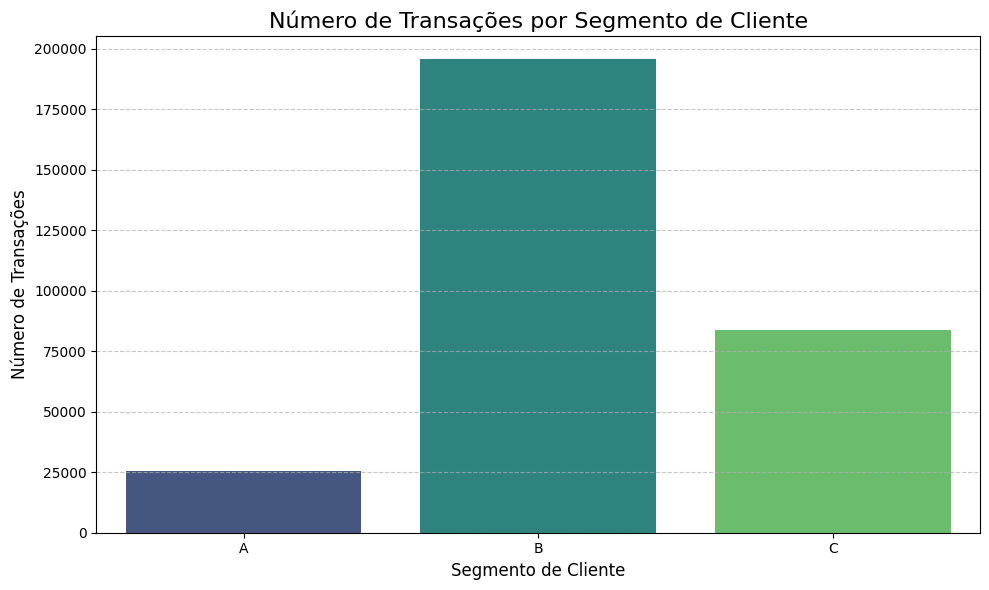

In [63]:
transactions_by_segment = df_limpo['Segmento_Cliente'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=transactions_by_segment.index, y=transactions_by_segment.values, palette='viridis')
plt.title('Número de Transações por Segmento de Cliente', fontsize=16)
plt.xlabel('Segmento de Cliente', fontsize=12)
plt.ylabel('Número de Transações', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Top Categorias de Produtos por Segmento de Cliente

Esta análise explora quais categorias de produtos são mais populares dentro de cada segmento de cliente, revelando preferências específicas de cada grupo.

/tmp/ipykernel_3359/2060230587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_category_by_segment = df_limpo.groupby('Segmento_Cliente')['Categoria_Produto'].value_counts().unstack(fill_value=0)


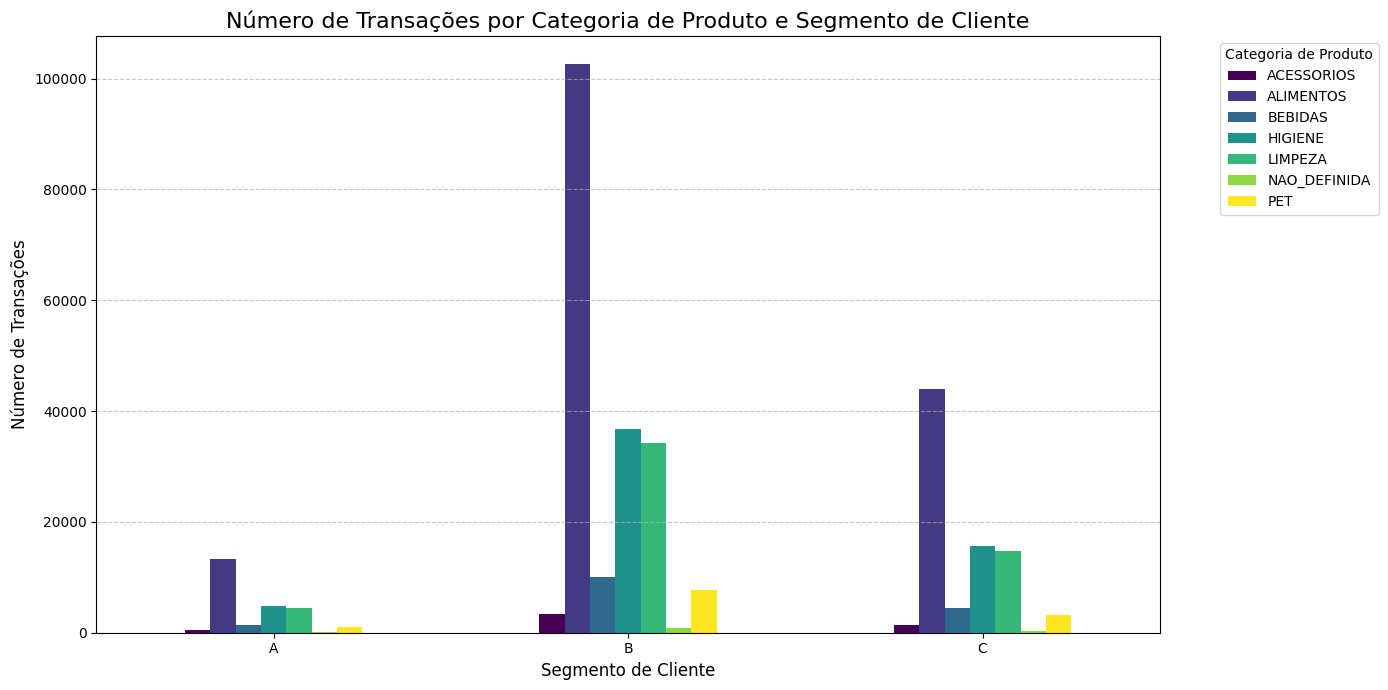

In [64]:
product_category_by_segment = df_limpo.groupby('Segmento_Cliente')['Categoria_Produto'].value_counts().unstack(fill_value=0)

# Select top 5 categories for each segment for better visualization, or all if few.
# Let's visualize all categories, but ensure they are sorted consistently.
all_categories = df_limpo['Categoria_Produto'].cat.categories
product_category_by_segment = product_category_by_segment.reindex(columns=all_categories)

product_category_by_segment.plot(kind='bar', stacked=False, figsize=(14, 7), colormap='viridis')
plt.title('Número de Transações por Categoria de Produto e Segmento de Cliente', fontsize=16)
plt.xlabel('Segmento de Cliente', fontsize=12)
plt.ylabel('Número de Transações', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Categoria de Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Distribuição de Transações por Gênero e Categoria de Produto

Esta análise investiga se existe uma relação entre o gênero do cliente e as categorias de produtos que eles compram.

/tmp/ipykernel_3359/2265897955.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_product_category = df_limpo.groupby('Genero_Cliente')['Categoria_Produto'].value_counts().unstack(fill_value=0)


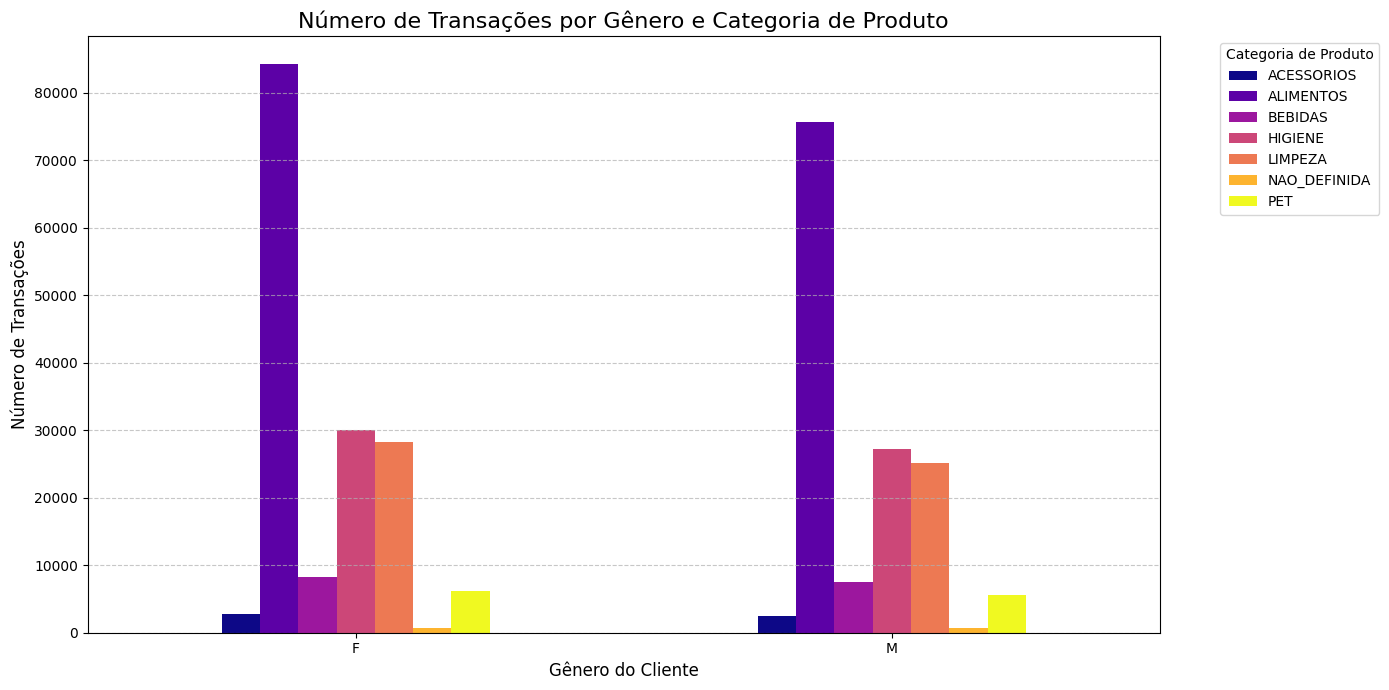

In [65]:
gender_product_category = df_limpo.groupby('Genero_Cliente')['Categoria_Produto'].value_counts().unstack(fill_value=0)

# Ensure all categories are present and sorted consistently
gender_product_category = gender_product_category.reindex(columns=all_categories)

gender_product_category.plot(kind='bar', stacked=False, figsize=(14, 7), colormap='plasma')
plt.title('Número de Transações por Gênero e Categoria de Produto', fontsize=16)
plt.xlabel('Gênero do Cliente', fontsize=12)
plt.ylabel('Número de Transações', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Categoria de Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. Limpeza e Preparação dos Dados (df_limpo):

Carregamento e Correção: O arquivo CSV foi carregado e o parâmetro sep=';' foi ajustado para garantir a
leitura correta dos dados.

Tradução e Padronização de Colunas: Todas as colunas foram traduzidas para o português e colunas 'Unnamed' foram removidas, resultando em cabeçalhos claros e concisos.

Tratamento de Valores Nulos: As linhas com valores nulos na coluna 'Data' foram removidas, reduzindo o conjunto de dados para 304.811 entradas, e não foram encontradas duplicatas após essa etapa.

Otimização de Tipos de Dados: Colunas categóricas (Genero_Cliente, Estado_Civil_Cliente, Historico_Familiar_Cliente, Segmento_Cliente, Categoria_Produto, Nome_Produto) foram convertidas para o tipo 'category' para otimização de memória.

Padronização de Texto: Colunas de texto foram convertidas para maiúsculas, espaços em branco foram removidos e o valor '#N/D' em 'Categoria_Produto' foi substituído por 'NAO_DEFINIDA'.

2. Análises e Insights Chave:

Tendências de Transação Mensal (Análise Temporal): Embora tenha havido um erro inicial de tipo na plotagem, a correção para converter 'AnoMes' para datetime permitiu visualizar as flutuações mensais no volume de transações, revelando padrões que podem indicar sazonalidade, mas sem um crescimento linear claro.

1. Número de Transações por Segmento de Cliente:

Segmento B é o mais ativo em volume de transações, seguido por Segmento C e, por último, Segmento A.

Ação: Focar estratégias de marketing e vendas no Segmento B, mas também identificar oportunidades para aumentar o engajamento nos Segmentos A e C.


2. Top Categorias de Produtos por Segmento de Cliente:

ALIMENTOS é a categoria dominante em todos os segmentos, seguida por HIGIENE e LIMPEZA.

Ação: Considerar a otimização da cadeia de suprimentos para ALIMENTOS e explorar vendas cruzadas ou pacotes com itens de HIGIENE e LIMPEZA. A categoria 'NAO_DEFINIDA' ainda merece atenção para categorização correta.

3. Distribuição de Transações por Gênero e Categoria de Produto:

As clientes femininas (F) mostram um volume de transações ligeiramente maior na maioria das categorias em comparação aos clientes masculinos (M).

Ação: Desenvolver campanhas de marketing direcionadas para cada gênero, capitalizando nas preferências observadas, e investigar mais a fundo o comportamento de compra de ambos os grupos para identificar nuances.

Estas análises fornecem uma base sólida para entender o comportamento do cliente e as tendências de produtos. Caso precise de mais alguma análise ou aprofundamento em algum ponto, por favor, me informe!